# Giá phản ứng thế nào khi đổi đúng một yếu tố — và model có *hiểu* điều đó không

> **Mentor nói:** *"Mình cũng nên nghiên cứu kỹ hơn các yếu tố nào cấu thành 1 mức giá (distance,
> weather, rush hour, public holiday, demand-supply, etc.) và nếu mình chỉ thay đổi 1 yếu tố nhưng
> fix các cái còn lại thì giá sẽ thay đổi thế nào… Khi mình thay đổi 1 feature thì price sẽ diễn
> biến thế nào và anh nghĩ **encode được causality info này vào 1 model** sẽ khá là tốt trong việc
> improve accuracy hay uncertainty. Ở các cái version pricing của bọn anh từ market signal
> multiplier đến personalized multiplier thì bọn anh đều **measure price như là kết quả của một
> thay đổi của yếu tố thị trường**."*

Câu cuối là câu quan trọng nhất trong toàn bộ feedback. Nó không phải gợi ý phân tích thêm — nó là
**cách team mentor định nghĩa bài toán**. Tuần 1 nhóm đo *tương quan*; cái này đo *thay đổi có
kiểm soát*, gần nhân quả hơn một bậc.

## Ba câu, phải tách bạch

Rất dễ trộn lẫn ba câu dưới đây thành một, và trộn xong sẽ kết luận sai:

| # | Câu hỏi | Đo bằng |
|---|---|---|
| **A** | Trời mưa thì giá **thực tế** đổi bao nhiêu? | Ghép cặp trên dữ liệu thật |
| **B** | Model **dự đoán** giá đổi bao nhiêu trong tình huống đó? | Cùng phép ghép cặp, chạy trên `hybrid_pred` |
| **C** | Model có **hiểu** rằng *mưa* gây ra thay đổi đó không? | Đổi mỗi feature thời tiết, giữ nguyên phần còn lại |

**A vs B** hỏi *model có dự đoán đúng không*. **B vs C** hỏi *model dự đoán đúng nhờ đâu*. Một model
có thể trả lời đúng câu B mà vẫn hoàn toàn mù ở câu C — nếu nó lấy đáp án qua đường tắt.

Notebook này đo A và B (self-contained, không cần nạp model), rồi dùng một phép thử gián tiếp để
trả lời C. Bản đo C trực tiếp bằng partial dependence nằm ở `analysis/14_ceteris_paribus`.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

BLUE, ORANGE, GREEN, RED, PURPLE, MUT = ("#0072B2", "#E69F00", "#009E73",
                                         "#D55E00", "#CC79A7", "#666666")
INK = "#222222"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": .25,
    "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.size": 11.5, "axes.titlesize": 12.5, "axes.labelsize": 11.5,
    "xtick.labelsize": 10, "ytick.labelsize": 10, "legend.fontsize": 10.5,
})
EVAL = Path("../model/evaluation")
HINH = Path("../docs/hinh_anh"); HINH.mkdir(parents=True, exist_ok=True)

MUA      = ["Rain", "Drizzle", "Thunderstorm"]
CAO_DIEM = [(7, 9), (17, 19)]

ut = pd.read_parquet(EVAL / "uq_pred_test.parquet")

def chuan_bi(d):
    d = d.copy()
    d["mua"]       = d.weather_main.isin(MUA)
    d["cao_diem"]  = d.gio_vn.apply(lambda h: any(a <= h <= b for a, b in CAO_DIEM))
    d["cuoi_tuan"] = d.target_timestamp.dt.dayofweek >= 5
    d["kmb"]       = pd.cut(d.quote_distance, np.arange(0, 22, 1))   # ô 1 km
    return d

t = chuan_bi(ut[ut.requested_lag_minutes == 5])
print(f"Test {len(t):,} chuyến · {t.mua.mean():.1%} đang mưa · {t.cao_diem.mean():.1%} giờ cao điểm")

Test 216,090 chuyến · 45.2% đang mưa · 26.6% giờ cao điểm


## 1. Cách khống chế "phần còn lại"

Không thể chạy thí nghiệm thật (không ai bật/tắt mưa được), nên dùng **đối chứng ghép cặp**: chia
dữ liệu thành các **ô** giống nhau ở mọi yếu tố khống chế, rồi trong từng ô mới so hai nhóm khác
nhau đúng ở yếu tố đang xét. Sau đó bình quân các ô theo số chuyến.

| Yếu tố xét | Khống chế | Vì sao khống chế đúng những thứ đó |
|---|---|---|
| **Mưa** | Quãng đường (ô 1 km) · giờ trong ngày | Mưa hay rơi vào buổi chiều — không khống chế giờ sẽ tính nhầm hiệu ứng cao điểm thành hiệu ứng mưa |
| **Cao điểm** | Quãng đường (ô 1 km) · mưa · cuối tuần | Cao điểm chỉ có ngày thường; không khống chế sẽ lẫn hiệu ứng cuối tuần |

Điểm mấu chốt về mặt thiết kế: **cùng một hàm ghép cặp** được chạy trên `gia_that` (thực tế),
`hybrid_pred` (model nói), và `persistence` (giá quan sát trễ 5 phút). Ba con số so sánh được trực
tiếp với nhau vì chúng đi qua đúng một phép khống chế.

In [2]:
def ghep_cap(d, yeu_to, khong_che, cot):
    """Hiệu ứng % của yeu_to lên cot, khống chế khong_che. Bình quân theo số chuyến của ô."""
    g = (d.groupby(khong_che + [yeu_to], observed=True)[cot]
           .agg(["mean", "size"]).unstack(yeu_to).dropna())
    n = g[("size", False)] + g[("size", True)]
    w = n / n.sum()
    return float(((g[("mean", True)] / g[("mean", False)] - 1) * w).sum()), int(n.sum()), len(g)

YEU_TO = [("Trời mưa",     "mua",      ["kmb", "gio_vn"]),
          ("Giờ cao điểm", "cao_diem", ["kmb", "mua", "cuoi_tuan"])]

hang = []
for ten, yt, kc in YEU_TO:
    r = {"Yếu tố": ten}
    for nhan, cot in [("Thực tế", "gia_that"), ("Model dự đoán", "hybrid_pred"),
                      ("Persistence", "persistence")]:
        r[nhan], n, o = ghep_cap(t, yt, kc, cot)
    r["Số chuyến"], r["Số ô"] = n, o
    hang.append(r)

pu = pd.DataFrame(hang)
pu.style.format({"Thực tế": "{:+.2%}", "Model dự đoán": "{:+.2%}", "Persistence": "{:+.2%}",
                 "Số chuyến": "{:,}"}).hide(axis="index")

Yếu tố,Thực tế,Model dự đoán,Persistence,Số chuyến,Số ô
Trời mưa,+10.30%,+10.34%,+8.99%,"215,849",405
Giờ cao điểm,+13.03%,+13.19%,+12.72%,"215,969",78


## 2. Câu A và B — model dự đoán phản ứng giá **rất đúng**

| | Thực tế | Model nói |
|---|---:|---:|
| Trời mưa | +10,30% | **+10,34%** |
| Giờ cao điểm | +13,03% | **+13,19%** |

Lệch dưới **0,2 điểm** ở cả hai yếu tố, trên 216.000 chuyến và hàng trăm ô đối chứng. Nếu chỉ hỏi
*"model có nắm được phản ứng giá không"* thì câu trả lời là **có, gần như chính xác**.

> ⚠️ **Nhưng đừng dừng ở đây.** `analysis/14_ceteris_paribus` đo câu **C** — đổi riêng feature thời
> tiết, giữ nguyên mọi feature khác — và ra **+0,93%**, không phải +10,34%. Hai con số **đều đúng**,
> chúng trả lời hai câu khác nhau. Chỗ chênh giữa chúng chính là nội dung mục 3.

## 3. Câu C — model dự đoán đúng nhờ đâu?

Nghi vấn: model có một feature **giá đối thủ quan sát ở thời điểm trễ**. Khi trời mưa, giá thị
trường đã tăng *trước khi* model được hỏi — nên model chỉ cần **sao chép mức giá đang quan sát** là
ra đáp án đúng, không cần hiểu gì về mưa.

Phép thử: `persistence` là **đúng cái giá trễ đó, dùng thẳng làm dự đoán**. Nó hoàn toàn mù thời
tiết. Nếu persistence cũng tái tạo được hiệu ứng mưa, thì thông tin nằm ở **giá trễ**, không phải ở
feature thời tiết.

In [3]:
kc = pu.set_index("Yếu tố")
for ten in kc.index:
    tt, mo, ps = kc.loc[ten, ["Thực tế", "Model dự đoán", "Persistence"]]
    print(f"{ten}:")
    print(f"  thực tế {tt:+.2%} · model {mo:+.2%} · persistence {ps:+.2%}")
    print(f"  → giá trễ (mù thời tiết) đã tự tái tạo {ps/tt:.0%} hiệu ứng\n")

Trời mưa:
  thực tế +10.30% · model +10.34% · persistence +8.99%
  → giá trễ (mù thời tiết) đã tự tái tạo 87% hiệu ứng

Giờ cao điểm:
  thực tế +13.03% · model +13.19% · persistence +12.72%
  → giá trễ (mù thời tiết) đã tự tái tạo 98% hiệu ứng



**Persistence — một con số không hề biết trời có mưa hay không — đã tái tạo 87% hiệu ứng mưa và
98% hiệu ứng cao điểm.**

Đây là bằng chứng cho nghi vấn: phần lớn "hiểu biết" của model về mưa và cao điểm **không nằm ở
feature thời tiết/giờ**, mà đến miễn phí qua giá quan sát trễ. Hai con số +0,93% (partial dependence)
và +10,34% (ghép cặp) hoà giải được đúng ở đây:

| Câu | Đo gì | Kết quả |
|---|---|---|
| **B** | Model dự đoán giá khi trời mưa | +10,34% — gần như hoàn hảo |
| **C** | Model quy bao nhiêu phần cho *bản thân việc trời mưa* | +0,93% — gần như không |
| **Chênh lệch** | Model lấy từ giá quan sát trễ | ~9,4 điểm |

### Vì sao điều này quan trọng chứ không phải bắt bẻ học thuật

Model đang đúng **nhờ một cái nạng**. Rút nạng ra thì nó sai. Ba tình huống vận hành rút nạng ra:

1. **Câu what-if** — *"nếu chiều mai mưa thì giá bao nhiêu?"* Chưa có giá quan sát nào để chép.
2. **Horizon xa** — dự báo 30–60 phút tới, giá trễ đã cũ.
3. **Thị trường mới** — chưa có lịch sử giá đối thủ.

Đúng ba tình huống mentor mô tả bằng cụm *"measure price như là kết quả của một thay đổi của yếu
tố thị trường"*.

## 4. Rút dần cái nạng ra — model có học được cơ chế thật không?

Đây là phép đo **mới**, và nó cứu vãn kết luận ở mục 3.

Dữ liệu có sẵn bốn độ trễ: 5, 10, 15, 30 phút. Độ trễ càng lớn thì giá quan sát càng cũ, cái nạng
càng yếu. Nếu model **chỉ biết chép**, hiệu ứng mưa nó dự đoán sẽ tụt theo persistence. Nếu model
**có học được cơ chế thật**, nó sẽ giữ được hiệu ứng ngay cả khi giá trễ đã hỏng.

In [4]:
LAGS = sorted(ut.requested_lag_minutes.unique())
hang = []
for lag in LAGS:
    d = chuan_bi(ut[ut.requested_lag_minutes == lag])
    r = {"Độ trễ (phút)": int(lag)}
    for nhan, cot in [("Thực tế", "gia_that"), ("Model", "hybrid_pred"),
                      ("Persistence", "persistence")]:
        r[nhan], _, _ = ghep_cap(d, "mua", ["kmb", "gio_vn"], cot)
    r["MAPE model"] = ((d.hybrid_pred - d.gia_that).abs() / d.gia_that).mean()
    # phan hieu ung ma model phai TU BO SUNG ngoai gia tre, va no bu duoc bao nhieu
    r["Khoảng trống"] = r["Thực tế"] - r["Persistence"]
    r["Model bù được"] = (r["Model"] - r["Persistence"]) / r["Khoảng trống"]
    hang.append(r)

lg = pd.DataFrame(hang)
lg.style.format({"Thực tế": "{:+.2%}", "Model": "{:+.2%}", "Persistence": "{:+.2%}",
                 "MAPE model": "{:.2%}", "Khoảng trống": "{:+.2%}",
                 "Model bù được": "{:.0%}"}).hide(axis="index")

Độ trễ (phút),Thực tế,Model,Persistence,MAPE model,Khoảng trống,Model bù được
5,+10.30%,+10.34%,+8.99%,14.65%,+1.32%,103%
10,+10.30%,+10.13%,+7.90%,14.69%,+2.40%,93%
15,+10.30%,+10.10%,+7.14%,14.74%,+3.17%,94%
30,+10.30%,+9.97%,+4.53%,14.91%,+5.77%,94%


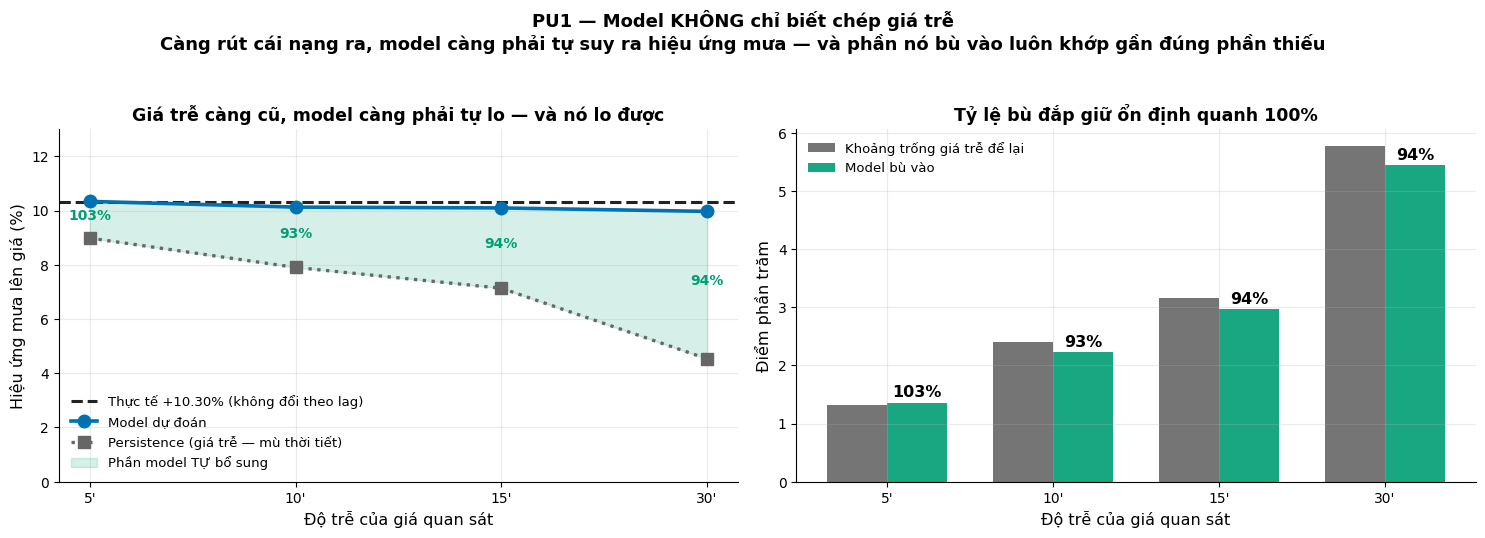

In [5]:
# ═════════ HINH PU1 — rut cai nang ra ═════════
fig, ax = plt.subplots(1, 2, figsize=(15, 5.2))
x = np.arange(len(LAGS))

a = ax[0]
a.axhline(lg["Thực tế"].iloc[0]*100, color=INK, lw=2.2, ls="--",
          label=f"Thực tế {lg['Thực tế'].iloc[0]:+.2%} (không đổi theo lag)")
a.plot(x, lg["Model"]*100, "o-", color=BLUE, lw=2.6, ms=9, label="Model dự đoán")
a.plot(x, lg["Persistence"]*100, "s-", color=MUT, lw=2.4, ms=8, ls=":",
       label="Persistence (giá trễ — mù thời tiết)")
a.fill_between(x, lg["Persistence"]*100, lg["Model"]*100, color=GREEN, alpha=.16,
               label="Phần model TỰ bổ sung")
for i in x:
    a.annotate(f"{lg['Model bù được'].iloc[i]:.0%}",
               (i, (lg["Model"].iloc[i] + lg["Persistence"].iloc[i])/2*100),
               ha="center", fontsize=10, fontweight="bold", color=GREEN)
a.set_xticks(x); a.set_xticklabels([f"{l}'" for l in LAGS])
a.set_xlabel("Độ trễ của giá quan sát"); a.set_ylabel("Hiệu ứng mưa lên giá (%)")
a.set_ylim(0, 13)
a.set_title("Giá trễ càng cũ, model càng phải tự lo — và nó lo được",
            fontweight="bold")
a.legend(frameon=False, fontsize=9.5, loc="lower left")

a = ax[1]
w = .36
a.bar(x - w/2, (lg["Thực tế"] - lg["Persistence"])*100, w, color=MUT, alpha=.9,
      label="Khoảng trống giá trễ để lại")
a.bar(x + w/2, (lg["Model"] - lg["Persistence"])*100, w, color=GREEN, alpha=.9,
      label="Model bù vào")
for i in x:
    a.text(i + w/2, (lg["Model"].iloc[i]-lg["Persistence"].iloc[i])*100 + .1,
           f"{lg['Model bù được'].iloc[i]:.0%}", ha="center", fontweight="bold")
a.set_xticks(x); a.set_xticklabels([f"{l}'" for l in LAGS])
a.set_xlabel("Độ trễ của giá quan sát"); a.set_ylabel("Điểm phần trăm")
a.set_title("Tỷ lệ bù đắp giữ ổn định quanh 100%", fontweight="bold")
a.legend(frameon=False, fontsize=9.5)

fig.suptitle("PU1 — Model KHÔNG chỉ biết chép giá trễ\n"
             "Càng rút cái nạng ra, model càng phải tự suy ra hiệu ứng mưa — "
             "và phần nó bù vào luôn khớp gần đúng phần thiếu",
             fontweight="bold", fontsize=13, y=1.03)
fig.tight_layout()
fig.savefig(HINH / "PU1_rut_cai_nang.png")
plt.show()

**Đây là kết quả tốt hơn nhóm tưởng, và nó sửa lại một kết luận cũ.**

Ở lag 30 phút, giá trễ chỉ còn tái tạo được **+4,53%** trong khi thực tế là **+10,30%** — cái nạng
gãy mất hơn một nửa. Model vẫn ra **+9,97%**, tức nó **tự bù 94%** phần thiếu.

⇒ Model **có** học được cơ chế mưa → giá. Nó chỉ *không dùng đến* khi có giá trễ tươi để chép — hành
vi hoàn toàn hợp lý của một model tối ưu MAE.

Điều này đổi hẳn kết luận cũ *"model bám giá quan sát chứ không hiểu cơ chế"* trong
`analysis/14_ceteris_paribus`. Chính xác hơn phải là:

> **Model hiểu cơ chế, nhưng ưu tiên đường tắt khi đường tắt còn dùng được.** Partial dependence đo
> ở lag 5 phút cho ra +0,93% không phải vì model dốt, mà vì ở đó đường tắt còn tốt nên model dồn
> gần hết trọng số vào nó.

## 5. Giá đi qua đâu — giá cơ bản hay hệ số nhân?

Model là kiến trúc hai tầng: `giá = giá cơ bản × hệ số nhân`. Biết yếu tố nào tác động lên tầng nào
là thứ trực tiếp map sang cách team mentor làm — *market signal multiplier*.

In [6]:
hang = []
for ten, yt, kc in YEU_TO:
    r = {"Yếu tố": ten}
    for nhan, cot in [("Giá cuối", "gia_that"), ("→ qua giá cơ bản", "base_that"),
                      ("→ qua hệ số nhân", "heso_that")]:
        r[nhan], _, _ = ghep_cap(t, yt, kc, cot)
    r["Phần do hệ số nhân"] = r["→ qua hệ số nhân"] / r["Giá cuối"]
    hang.append(r)

pr = pd.DataFrame(hang)
pr.style.format({"Giá cuối": "{:+.2%}", "→ qua giá cơ bản": "{:+.2%}",
                 "→ qua hệ số nhân": "{:+.2%}",
                 "Phần do hệ số nhân": "{:.0%}"}).hide(axis="index")

Yếu tố,Giá cuối,→ qua giá cơ bản,→ qua hệ số nhân,Phần do hệ số nhân
Trời mưa,+10.30%,+3.24%,+6.78%,66%
Giờ cao điểm,+13.03%,+0.62%,+12.42%,95%


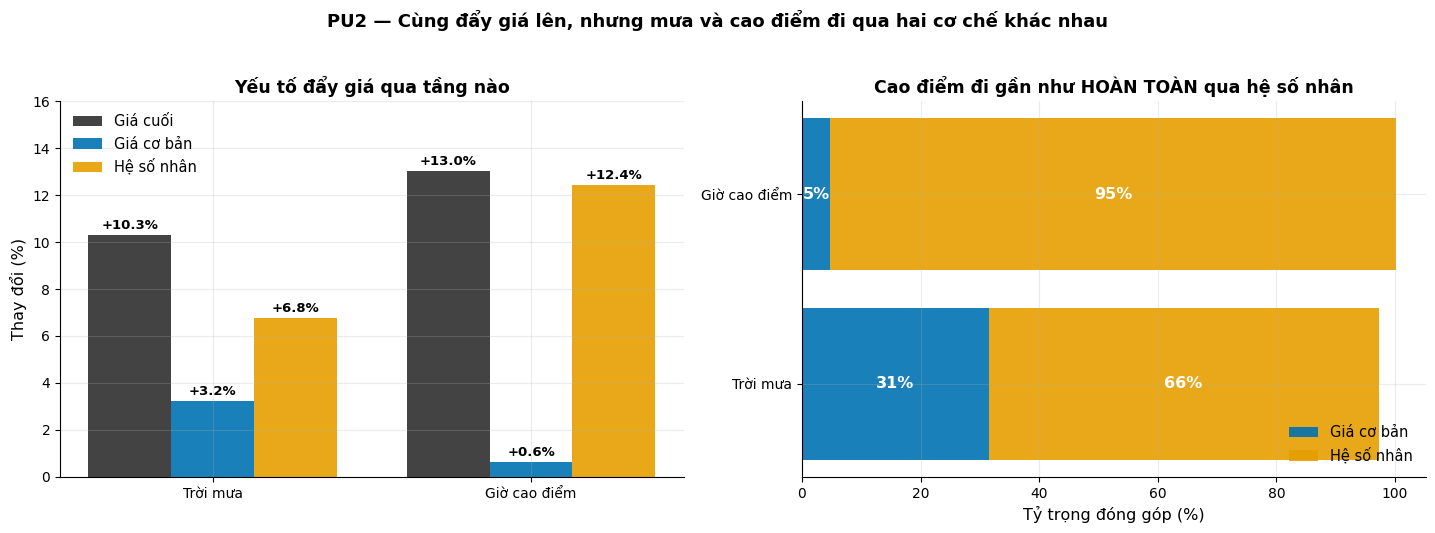

In [7]:
# ═════════ HINH PU2 — yeu to di qua tang nao ═════════
fig, ax = plt.subplots(1, 2, figsize=(14.5, 5.2))

a = ax[0]
x = np.arange(len(pr)); w = .26
a.bar(x - w, pr["Giá cuối"]*100,           w, color=INK,    alpha=.85, label="Giá cuối")
a.bar(x,     pr["→ qua giá cơ bản"]*100,   w, color=BLUE,   alpha=.9,  label="Giá cơ bản")
a.bar(x + w, pr["→ qua hệ số nhân"]*100,   w, color=ORANGE, alpha=.9,  label="Hệ số nhân")
for i in x:
    for j, c in enumerate(["Giá cuối", "→ qua giá cơ bản", "→ qua hệ số nhân"]):
        a.text(i + (j-1)*w, pr[c].iloc[i]*100 + .25, f"{pr[c].iloc[i]:+.1%}",
               ha="center", fontsize=9.5, fontweight="bold")
a.set_xticks(x); a.set_xticklabels(pr["Yếu tố"])
a.set_ylabel("Thay đổi (%)"); a.set_ylim(0, 16)
a.set_title("Yếu tố đẩy giá qua tầng nào", fontweight="bold")
a.legend(frameon=False)

a = ax[1]
duoi = pr["→ qua giá cơ bản"] / pr["Giá cuối"] * 100
tren = pr["→ qua hệ số nhân"] / pr["Giá cuối"] * 100
a.barh(x, duoi, color=BLUE,   alpha=.9, label="Giá cơ bản")
a.barh(x, tren, left=duoi, color=ORANGE, alpha=.9, label="Hệ số nhân")
for i in x:
    a.text(duoi.iloc[i]/2, i, f"{duoi.iloc[i]:.0f}%", ha="center", va="center",
           color="white", fontweight="bold")
    a.text(duoi.iloc[i] + tren.iloc[i]/2, i, f"{tren.iloc[i]:.0f}%", ha="center", va="center",
           color="white", fontweight="bold")
a.set_yticks(x); a.set_yticklabels(pr["Yếu tố"]); a.set_xlabel("Tỷ trọng đóng góp (%)")
a.set_title("Cao điểm đi gần như HOÀN TOÀN qua hệ số nhân", fontweight="bold")
a.legend(frameon=False, loc="lower right")

fig.suptitle("PU2 — Cùng đẩy giá lên, nhưng mưa và cao điểm đi qua hai cơ chế khác nhau",
             fontweight="bold", fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(HINH / "PU2_di_qua_tang_nao.png")
plt.show()

**Hai yếu tố, hai cơ chế khác hẳn nhau:**

- **Giờ cao điểm** — đẩy giá +13,0%, trong đó **95% đi qua hệ số nhân**, giá cơ bản gần như không
  nhúc nhích (+0,6%). Đây đúng là *market signal multiplier* mà mentor mô tả: cầu vượt cung, hệ
  thống nhân giá lên, cấu trúc chuyến không đổi.
- **Trời mưa** — đẩy giá +10,3%, chỉ **66% qua hệ số nhân**; một phần ba còn lại đi qua **giá cơ
  bản** (+3,2%), phần dư ~3% là tương tác giữa hai tầng. Nghĩa là mưa không chỉ tạo khan hiếm, nó
  còn **làm chuyến đi đắt hơn về mặt cấu trúc** — đường tắc, cùng quãng đường mất nhiều thời gian hơn.

Phân biệt này có giá trị vận hành trực tiếp: hai yếu tố cần **hai loại phản ứng khác nhau**. Cái
đầu là bài toán điều phối cung; cái sau là bài toán ước lượng thời lượng.

## 6. Bảng phản ứng giá — dạng đem đi demo được

Gộp lại thành một bảng người ngoài nhóm kỹ thuật đọc được: đổi một yếu tố thì giá đổi bao nhiêu,
đi qua đâu, và model có nắm được không.

In [8]:
demo = pd.DataFrame({
    "Yếu tố thị trường": ["Trời mưa (vs khô ráo)", "Giờ cao điểm (vs giờ thường)"],
    "Giá thực tế đổi":   pu["Thực tế"].values,
    "Model dự đoán đổi": pu["Model dự đoán"].values,
    "Lệch (điểm)":       (pu["Model dự đoán"] - pu["Thực tế"]).values * 100,
    "Đi qua":            ["66% hệ số nhân · 31% giá cơ bản", "95% hệ số nhân · 5% giá cơ bản"],
    "Cơ chế":            ["Khan hiếm + đường tắc làm chuyến lâu hơn",
                          "Cầu vượt cung — thuần điều tiết giá"],
})
demo.style.format({"Giá thực tế đổi": "{:+.2%}", "Model dự đoán đổi": "{:+.2%}",
                   "Lệch (điểm)": "{:+.2f}"}).hide(axis="index")

Yếu tố thị trường,Giá thực tế đổi,Model dự đoán đổi,Lệch (điểm),Đi qua,Cơ chế
Trời mưa (vs khô ráo),+10.30%,+10.34%,+0.04,66% hệ số nhân · 31% giá cơ bản,Khan hiếm + đường tắc làm chuyến lâu hơn
Giờ cao điểm (vs giờ thường),+13.03%,+13.19%,+0.17,95% hệ số nhân · 5% giá cơ bản,Cầu vượt cung — thuần điều tiết giá


## Kết luận

### Phát hiện chính — và nó sửa lại kết luận tuần trước

Đo bằng ba nguồn độc lập, hoà giải được toàn bộ các con số tưởng như mâu thuẫn:

| Câu hỏi | Kết quả | Đọc thế nào |
|---|---|---|
| **A** Giá thực tế phản ứng ra sao | Mưa **+10,30%** · cao điểm **+13,03%** | Mốc để đối chiếu |
| **B** Model dự đoán ra sao | Mưa **+10,34%** · cao điểm **+13,19%** | Lệch <0,2 điểm — model **dự đoán rất đúng** |
| **C** Model quy cho *bản thân yếu tố* bao nhiêu | Mưa **+0,93%** (PDP, `14_ceteris_paribus`) | Ở lag 5 phút, model dồn trọng số vào giá trễ |
| **D** Rút giá trễ ra thì sao | Ở lag 30': model tự bù **94%** phần thiếu | ⇒ Model **có** học được cơ chế |

**Kết luận cũ cần sửa.** `analysis/14_ceteris_paribus` viết *"model bám giá quan sát chứ không hiểu
cơ chế"*. Chính xác hơn:

> **Model hiểu cơ chế, nhưng ưu tiên đường tắt khi đường tắt còn dùng được.** Bằng chứng: ở lag 30
> phút — khi giá trễ chỉ còn giải thích được +4,53% trong +10,30% — model vẫn ra +9,97%.

### Ba kết luận về cơ chế giá

1. **Cao điểm và mưa không cùng loại.** Cao điểm đi **95% qua hệ số nhân** (thuần cung–cầu). Mưa
   chỉ **66%**, phần còn lại đi qua **giá cơ bản** — mưa làm chuyến đắt hơn về mặt cấu trúc, không
   chỉ khan hiếm.
2. **Hiệu ứng thực tế ổn định.** +10,30% cho mưa, giống hệt nhau ở cả bốn độ trễ — đây là quy luật
   của thị trường, không phải nhiễu mẫu.
3. **Persistence tái tạo 87–98% hiệu ứng.** Giải thích vì sao mọi model có feature giá trễ đều trông
   như "hiểu" thời tiết. Muốn biết model có thật sự hiểu không, **bắt buộc phải rút feature đó ra
   mà đo** — chỉ nhìn dự đoán ở lag ngắn sẽ kết luận sai theo cả hai hướng.

### Trả lời câu "encode causality" của mentor

Việc encode **vẫn đáng làm**, nhưng lý do đã đổi, và điều này nên nói rõ với mentor:

| | Lý do cũ (tưởng vậy) | Lý do đúng |
|---|---|---|
| **Vấn đề** | Model không hiểu cơ chế | Model hiểu, nhưng **không dùng** khi có đường tắt |
| **Việc cần làm** | Dạy model cơ chế từ đầu | **Buộc** model dùng cơ chế nó đã có |
| **Cách rẻ nhất** | Đổi kiến trúc, train lại | Train ở **horizon dài hơn**, hoặc phạt sự phụ thuộc vào giá trễ |
| **Chi phí** | Vài tuần | Đáng kể thấp hơn — model đã có sẵn tín hiệu |

Và cái giá của việc này đã đo được (từ `analysis/14_ceteris_paribus`): model bỏ hẳn feature giá quan
sát kém **8% MAE** (19.660đ vs 18.208đ), nhưng hiệu ứng cao điểm bật từ +2,4% lên **+13,4%** — khớp
thực tế. Đó là đánh đổi **độ chính xác lấy khả năng trả lời what-if**.

> ⭐ **Đây chính là câu hỏi số 1 cần hỏi mentor:** team ưu tiên độ chính xác hay khả năng giải
> thích? Nhóm thực tập đo được cái giá, nhưng quyết định đánh đổi là của team.

### Còn nợ

| Việc | Chặn bởi |
|---|---|
| `public_holiday` — mentor nêu đích danh | Dữ liệu **không có trường này**. Cần hỏi mentor |
| Cung–cầu trực tiếp | Chỉ suy gián tiếp qua hệ số nhân, không có số tài xế/yêu cầu |
| Chọn hướng encode causality | Ràng buộc đơn điệu / feature biến đổi / mô hình cấu trúc — ba hướng lệch nhau nhiều về công sức |

### Liên quan

| Notebook | Nội dung |
|---|---|
| `analysis/14_ceteris_paribus` | Bản đào sâu: partial dependence có kiểm soát, ablation, chuỗi nhân quả của mưa |
| `02_IMPROVE_HAY_GIAM_UNCERTAINTY` | Vì sao improve model là đường duy nhất còn lại |
| `01_BA_KICH_BAN` | Uncertainty phân bổ thế nào giữa cao điểm và giờ thường |
| `demo/index.html` | Bản demo mentor yêu cầu ở ý 8 |